<a href="https://colab.research.google.com/github/Abhyansh-sahu/Predict-Heart-Disease-Logistic-Regression-/blob/main/Linear_regression_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download nikhil7280/student-performance-multiple-linear-regression

Dataset URL: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression
License(s): other
100% 48.5k/48.5k [00:00<00:00, 1.74MB/s]



In [ ]:
! unzip /content/student-performance-multiple-linear-regression.zip

Archive:  /content/student-performance-multiple-linear-regression.zip
replace Student_Performance.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv('/content/Student_Performance.csv')
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
data['Extracurricular Activities'] = data['Extracurricular Activities'].replace({'No': 0, 'Yes': 1})
data.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [ ]:
x=data[['Hours Studied','Previous Scores','Extracurricular Activities']]
y=data['Performance Index']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
model.predict(x_test)

array([54.53487483, 23.13776577, 47.59996133, ..., 17.033805  ,
       63.06187894, 45.37893367])

In [ ]:
train_accuracy=r2_score(y_train, model.predict(x_train))
test_accuracy=r2_score(y_test, model.predict(x_test))
print(train_accuracy)
print(test_accuracy)

0.9860936436517252
0.9861352257658504


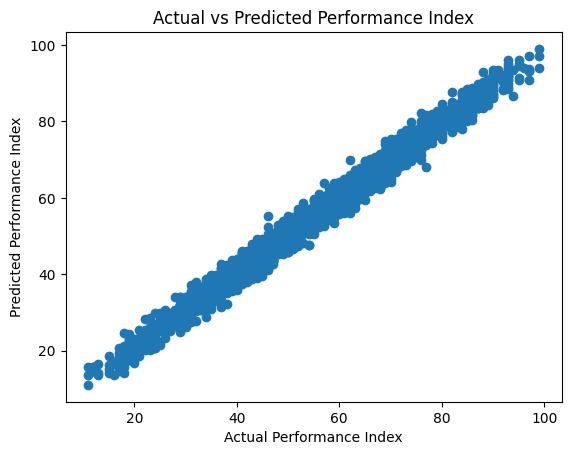

In [ ]:
plt.scatter(y_test, model.predict(x_test))
plt.xlabel('Actual Performance Index')
plt.ylabel('Predicted Performance Index')
plt.title('Actual vs Predicted Performance Index')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()